<a href="https://colab.research.google.com/github/shinyunji3236-cmyk/2026_datascience_teamproject/blob/main/Data_Science_Team_Project_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

In [ ]:
import os
import pandas as pd
import numpy as np

# 'huggingface' 사이트에 로그인 후 데이터 받아오기
df = pd.read_csv("hf://datasets/meal-bbang/Korean_message/lgaidataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# 데이터 잘 받아와졌나 확인하기

print("DataFrame Info:")
df.info()
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Columns:")
print(df.columns)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19009 entries, 0 to 19008
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    16309 non-null  float64
 1   content  19009 non-null  object 
 2   class    19009 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 445.7+ KB

First 5 Rows:
   index                                            content  class
0    2.0  엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?      2
1    2.0  [국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...      2
2    2.0  엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...      2
3    3.0  엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...      2
4    5.0  엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...      2

Data Columns:
Index(['index', 'content', 'class'], dtype='object')


In [ ]:
# 라이브러리 및 한글 폰트 설치 (Colab 내 한글 깨짐 현상을 해결)

!sudo apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (27.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

▶ 결측치 확인
index      2700
content       0
class         0
dtype: int64

▶ 라벨 비율 확인 (%)
class
2    55.4
1    30.4
3    14.2
Name: proportion, dtype: float64


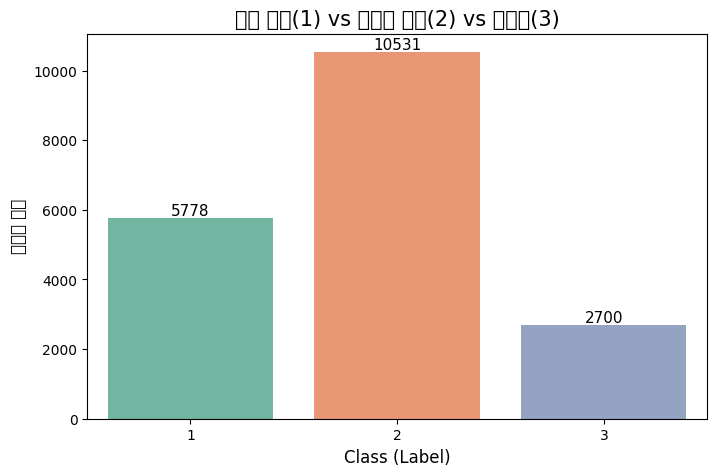

In [ ]:
# 결측치 확인
print("▶ 결측치 확인")
print(df.isnull().sum())

# 확인 결과 단순한 행 번호(index)에 2700개의 결측치(상관없는 값) 존재
# 확인해보니 미분류 값에 id 번호가 안 적혀있어 index가 결측치 처리 된 듯
# 어차피 index값은 분석과 상관없어서 preprocessing 할 때 df = df.drop(columns=['index'])로 삭제 가능
# 우리가 분석해야 할 실제 문자 메시지 내용(content) 결측치 0개
# 스미싱 여부를 알려주는 정답 라벨(class) 결측치 0개
# 여기서 말하는 결측치는 빈칸이 있나, 정답 라벨에 다른 숫자가 들어있나를 확인한 것

# 라벨(1: 정상, 2: 스미싱, 3: 미분류) 분포 확인
print("\n▶ 라벨 비율 확인 (%)")
label_counts = df['class'].value_counts(normalize=True) * 100
#.value_counts(): 해당 열에 존재하는 고유한 값들(1, 2, 3)이 각각 몇 번씩 등장했는지 빈도를 계산합니다.
#normalize=True: 이 옵션을 주면 단순 개수가 아니라 전체에서 차지하는 비율(상대 빈도)을 0에서 1 사이의 소수로 계산해 줍니다.
#* 100: 소수점 비율을 백분율(%) 단위로 변환합니다.

#.round(2): 소수점 아래 2번째 자리까지만 반환하고 반올림하여 가독성을 높입니다.
print(label_counts.round(2))

# 확인 결과 스미싱이 55.4%, 정상이 30.4%, 미분류가 14.2%
# 14% 미분류된 데이터는 삭제할지 preprocessing을 거쳐서 학습에 쓸지 추후 결정

# 라벨 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class', hue='class', data=df, palette='Set2', legend=False)
# 범주형 데이터의 빈도수를 자동으로 계산해 막대그래프(Bar chart)로 그려주는 Seaborn의 대표 함수입니다. (value_counts() 결과를 시각화한다고 보시면 됩니다.)
# legend=False: hue를 지정하면 자동으로 생성되는 범례(Legend) 창이 화면을 가리지 않도록 숨깁니다.
plt.title('정상 문자(1) vs 스미싱 문자(2) vs 미분류(3)', fontsize=15)
plt.xlabel('Class (Label)', fontsize=12)
plt.ylabel('데이터 개수', fontsize=12)

# 막대 그래프 위에 정확한 개수 표시
for p in ax.patches:
  # for p in ax.patches: ax.patches는 그래프에 그려진 '막대(도형) 객체들'의 리스트입니다.
  # 여기서는 클래스 1, 2, 3에 해당하는 3개의 막대가 담겨 있으며, 루프를 돌며 하나씩 p라는 변수로 꺼냅니다.
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, xytext=(0, 5),
                textcoords='offset points')
# ax.annotate(...): 그래프 위의 특정 좌표에 텍스트(주석)를 달아주는 메서드
# (p.get_x() + p.get_width() / 2., p.get_height()): 글자가 들어갈 X, Y 절대 좌표입니다.
# X 좌표: 막대의 시작점(p.get_x())에 막대 두께의 절반(p.get_width() / 2.)을 더해 막대의 정중앙으로 맞춥니다.
# Y 좌표: 막대의 꼭대기 높이(p.get_height())로 지정합니다.
# ha='center', va='center': 정렬 기준입니다. 각각 Horizontal Alignment(가로 정렬), Vertical Alignment(세로 정렬)를 의미하며, 글자의 중심을 위에서 지정한 좌표에 딱 맞추도록 만듭니다.
# xytext=(0, 5): 글자를 좌표 지정 위치에서 약간 이동시키는 오프셋(Offset) 값입니다.
# X축으로는 0, Y축으로는 위쪽으로 5포인트만큼 띄우라는 뜻입니다. (이게 없으면 글자가 막대 선 딱 머리에 걸쳐서 답답해 보입니다.)
# textcoords='offset points': xytext에서 지정한 (0, 5)가 절대 좌표가 아니라, 현재 기준 좌표로부터 '상대적인 포인트 공간(픽셀 개념)'만큼 이동하겠다는 기준을 세워주는 설정입니다.

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

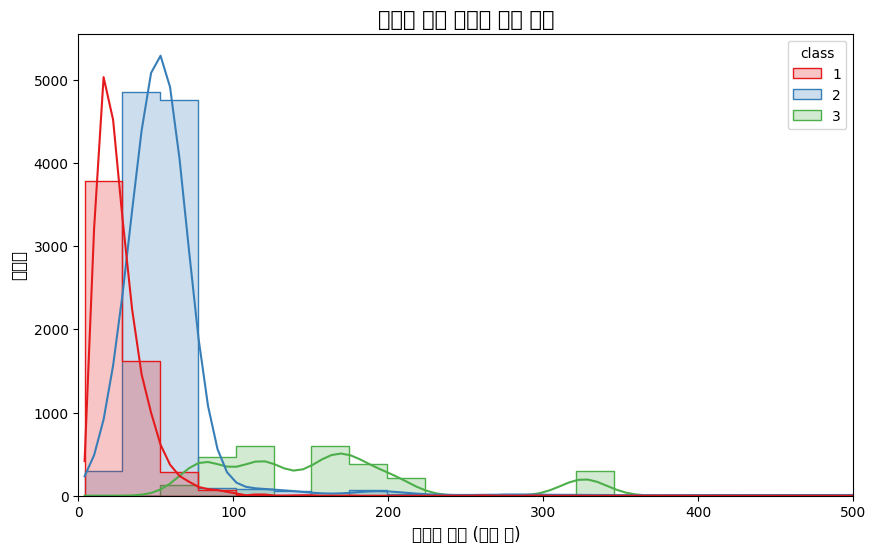

In [ ]:
# 문자 메시지 길이에 따른 분포 확인
# 메시지 내용이 담긴 실제 column명 'content'를 사용
df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='class', bins=50, kde=True, palette='Set1', element="step")
# bins : 히스토그램 한 칸의 간격(여기선 50개)
# element="step": 막대 내부를 가득 채우지 않고 계단식(Step) 선 형태로 매끄럽게 연결하여 그립니다.
# hue로 인해 여러 개의 히스토그램이 겹칠 때, 막대끼리 서로 가려져 안 보이는 현상을 방지해 주는 매우 센스 있는 옵션입니다.
plt.title('라벨별 문자 메시지 길이 분포', fontsize=15)
plt.xlabel('메시지 길이 (글자 수)', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xlim(0, 500)
# x축 범위 제한(0 이상 500 이하)
plt.show()

# 확인 결과, 대부분 메시지 길이는 100자 이하로 짧다
# 스미싱 문자가 일반 문자보다 상대적으로 길다
# 미분류된 메시지의 경우 메시지 길이가 100자부터 300자 이상까지 매우 불규칙적으로 퍼져있다. 이상치 처리 필요할 듯!

# 정상 문자와 스미싱 문자를 구분할 때, 메시지의 글자수를 feature로 쓸 수 있을 듯

In [ ]:
# 한국어 형태소 분석기 설치
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.5 MB/s eta 0:00:00


/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1166/3912707355.py:50: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  plt.tight_layo

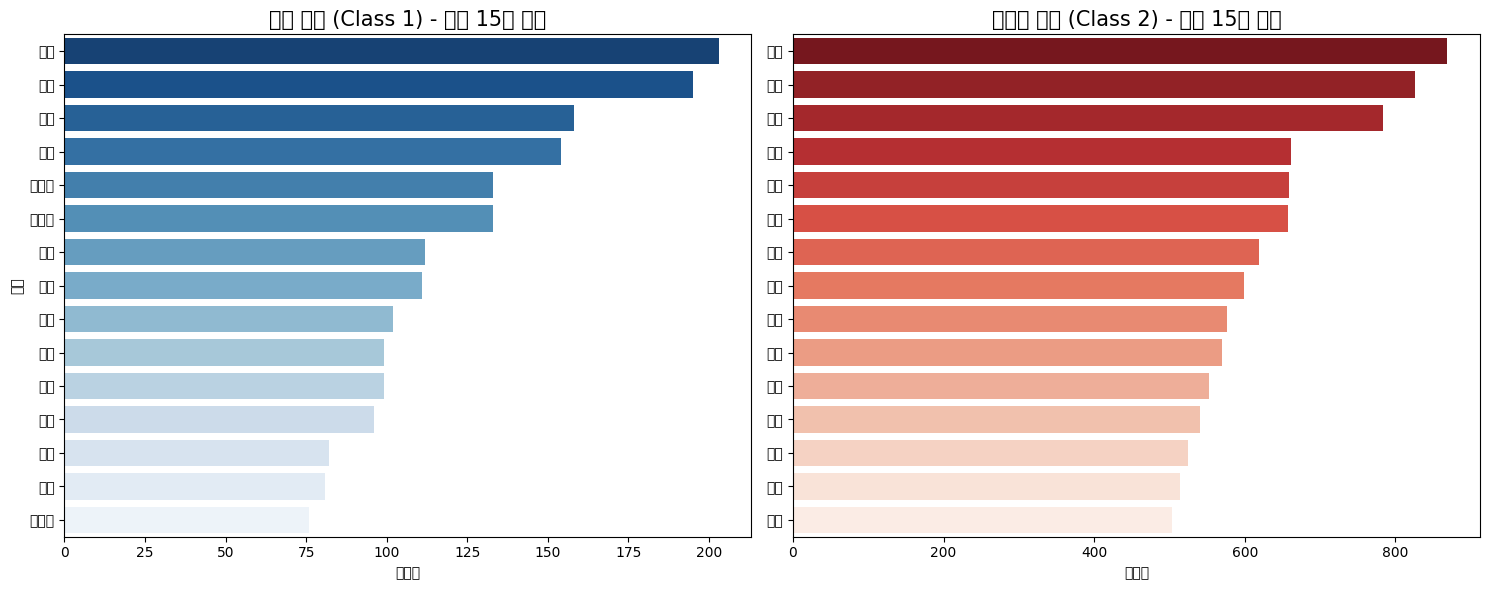

In [ ]:
# 특정 단어가 라벨 별로 얼마나 자주 등장하는지 확인 (우선 상위 15개만)

from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 명사 추출 및 빈도수 계산 함수 정의
def get_top_nouns(text_series, top_n=15):
    all_nouns = []
    # 각 문자 메시지에서 명사만 추출
    for text in text_series.astype(str):
        nouns = okt.nouns(text)
        # 1글자 단어는 의미를 파악하기 어려우므로 제외 (예: '것', '수', '등')
        nouns = [word for word in nouns if len(word) > 1]
        all_nouns.extend(nouns)

    # 단어별 빈도수 계산 후 상위 N개 반환
    counter = Counter(all_nouns)
    return counter.most_common(top_n)
    # counter은 단어와 해당 단어의 빈도수를 묶은 튜플로 리턴

# 클래스별로 데이터 분리 및 빈도수 계산
# class 1 (정상 문자), class 2 (스미싱 문자)
normal_texts = df[df['class'] == 1]['content']
smishing_texts = df[df['class'] == 2]['content']

top_normal_words = get_top_nouns(normal_texts, 15)
top_smishing_words = get_top_nouns(smishing_texts, 15)

# 데이터프레임으로 변환
df_normal = pd.DataFrame(top_normal_words, columns=['Word', 'Count'])
df_smishing = pd.DataFrame(top_smishing_words, columns=['Word', 'Count'])

# 시각화 (두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# plt.subplots(1, 2, ...): 하나의 화면(Figure) 안에 여러 개의 그래프(Axes)를 배치할 때 쓰는 가장 중요한 메서드입니다.
# 첫 번째 인자는 행(Row)의 개수, 두 번째 인자는 열(Column)의 개수입니다. 여기서는 1행 2열로 도화지를 쪼개어 2개의 그래프를 좌우로 배치하겠다는 의미입니다.

# 정상 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_normal, ax=axes[0], palette='Blues_r', hue='Word', legend=False)
axes[0].set_title('정상 문자 (Class 1) - 상위 15개 명사', fontsize=15)
axes[0].set_xlabel('빈도수')
axes[0].set_ylabel('단어')

# 스미싱 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_smishing, ax=axes[1], palette='Reds_r', hue='Word', legend=False)
axes[1].set_title('스미싱 문자 (Class 2) - 상위 15개 명사', fontsize=15)
axes[1].set_xlabel('빈도수')
axes[1].set_ylabel('')

plt.tight_layout()
# 요소들이 겹치지 않고 도화지 내에 황금 비율로 쏙 들어가도록 여백을 자동으로 최적화 조절해 주는 명령어입니다.
plt.show()

# Data Preprocessing

In [ ]:
#신윤지 작성

# 1. 미분류 데이터(3) 제거 및 정상(1)/스미싱(2)만 남기기
df = df[df['class'].isin([1, 2])].reset_index(drop=True)

# 2. 분석에 불필요한 index 컬럼 삭제 (존재할 경우)
if 'index' in df.columns:
    df = df.drop(columns=['index'])

#문자 메시지에는 특수문자, 의미 없는 이모티콘, 공백, 국문/영문이 복잡하게 섞여 있음.
#특히 스미싱 문자는 [Web발신], (광고) 같은 패턴이나 특수 기호가 많으므로 이를 정규표현식(re)으로 정제.

#3. 텍스트 정제-한글, 영문, 숫자와 필수 특수기호만 남
import re

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    # 한글, 영문, 숫자, 그리고 스미싱에 자주 쓰이는 특수문자([], (), /, ., :)만 남기고 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\[\]\(\)\/\.\:]', ' ', text)
    # 연속된 공백 하나로 줄이기
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_content'] = df['content'].apply(clean_text)

#4. 이상치 제거-글자 수가 0이거나 미만인 데이터(정제 후 빈 칸이 된 데이터), 혹은 데이터의 99%가 포함되는 범위를 벗어난 너무 긴 메시지(예: 500자 초과)는 학습에서 제외
# 정제 후 글자 수 다시 계산
df['text_length'] = df['cleaned_content'].apply(len)

# 글자 수가 너무 짧거나(내용 없음) 500자를 초과하는 극단적 이상치 제거
df = df[(df['text_length'] > 0) & (df['text_length'] <= 500)].reset_index(drop=True)

#5. 토큰화(Tokenization) 및 불용어 제거-명사 분석 시 상위에 나왔던 단어 중 '회원님', '고객님'처럼 정상/스미싱 모두에 너무 흔하게 쓰여서 분별력이 없는 단어나, 의미 없는 조사들을 리스트로 만들어 제외

# 불용어 리스트 예시-추가 확장 필요
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

def tokenize_and_remove_stopwords(text):
    # 명사뿐만 아니라 동사, 형용사까지 형태소 분석을 원하면 okt.morphs() 사용
    # 단어 고유의 의미를 살리려면 stem=True 옵션 추가 가능
    tokens = okt.nouns(text)
    # 1글자 제어 및 불용어 제거
    meaningful_tokens = [word for word in tokens if len(word) > 1 and word not in stopwords]
    return ' '.join(meaningful_tokens) # 단어들을 공백으로 이어붙인 문자열 반환

df['tokenized_content'] = df['cleaned_content'].apply(tokenize_and_remove_stopwords)

#6. 피처 생성 및 벡터화(ML기준)

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import numpy as np

# 1. 텍스트를 TF-IDF 행렬로 변환 (자주 나오면서도 독특한 단어에 가중치 부여)
# 전체 문서에서 흔하지 않은 단어가 특정 글에 집중적으로 등장하면 점수를 높게 주기.
tfidf = TfidfVectorizer(max_features=3000) # 상위 3000개 단어만 사용
X_tfidf = tfidf.fit_transform(df['tokenized_content'])

# 2. 내가 만든 파생 변수(메시지 길이)를 2차원 배열로 변환 후 정규화(Scaling)
# 원래 메시지들의 글자 수(45자, 120자, 500자)를 그대로 쓰면 숫자가 너무 커서 TF-IDF 점수들이 무시됨.
# StandardScaler() 사용해 normailzation 수행.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_length = scaler.fit_transform(df[['text_length']])

# 3. TF-IDF 단어 피처와 길이 피처를 하나로 결합 (hstack)
# 총 3001개의 열을 가진 최종 데이터 행렬 도출(0~2999번째 : TF-IDF score, 3000번째 : normaiza)
X_final = hstack([X_tfidf, X_length])
y_final = df['class'].values


# Modeling & Validation

# Interpretation